In [11]:
# Milestone 1

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
print('Libraries loaded.')

Libraries loaded.


In [12]:
df = pd.read_csv('data/heart_disease_uci.csv')print('=' * 60)
print('HEART DISEASE UCI - FULL PIPELINE')
print('=' * 60)
print(f'\n[1] Dataset Shape: {df.shape[0]} rows x {df.shape[1]} columns')
print('\n[2] Column Data Types:')
print(df.dtypes.to_string())
print('\n[3] First 5 Rows:')
df.head()

HEART DISEASE UCI - FULL PIPELINE

[1] Dataset Shape: 920 rows x 16 columns

[2] Column Data Types:
id            int64
age           int64
sex          object
dataset      object
cp           object
trestbps    float64
chol        float64
fbs          object
restecg      object
thalch      float64
exang        object
oldpeak     float64
slope        object
ca          float64
thal         object
num           int64

[3] First 5 Rows:


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [13]:
print('[4] Missing Values (count & %):')
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_df[missing_df['Missing Count'] > 0].to_string())

print('\n[5] Descriptive Statistics (numeric):')
print(df.describe().to_string())

print('\n[6] Target Variable Distribution (num):')
print(df['num'].value_counts().to_string())

print('\n[7] Categorical Unique Values:')
cat_cols = ['sex', 'dataset', 'cp', 'restecg', 'slope', 'thal']
for col in cat_cols:
    print(f'  {col}: {df[col].dropna().unique().tolist()}')

print('\n[8] Duplicate Rows:', df.duplicated().sum())

[4] Missing Values (count & %):
          Missing Count  Missing %
trestbps             59       6.41
chol                 30       3.26
fbs                  90       9.78
restecg               2       0.22
thalch               55       5.98
exang                55       5.98
oldpeak              62       6.74
slope               309      33.59
ca                  611      66.41
thal                486      52.83

[5] Descriptive Statistics (numeric):
               id         age    trestbps        chol      thalch     oldpeak          ca         num
count  920.000000  920.000000  861.000000  890.000000  865.000000  858.000000  309.000000  920.000000
mean   460.500000   53.510870  132.132404  199.130337  137.545665    0.878788    0.676375    0.995652
std    265.725422    9.424685   19.066070  110.780810   25.926276    1.091226    0.935653    1.142693
min      1.000000   28.000000    0.000000    0.000000   60.000000   -2.600000    0.000000    0.000000
25%    230.750000   47.000000  120

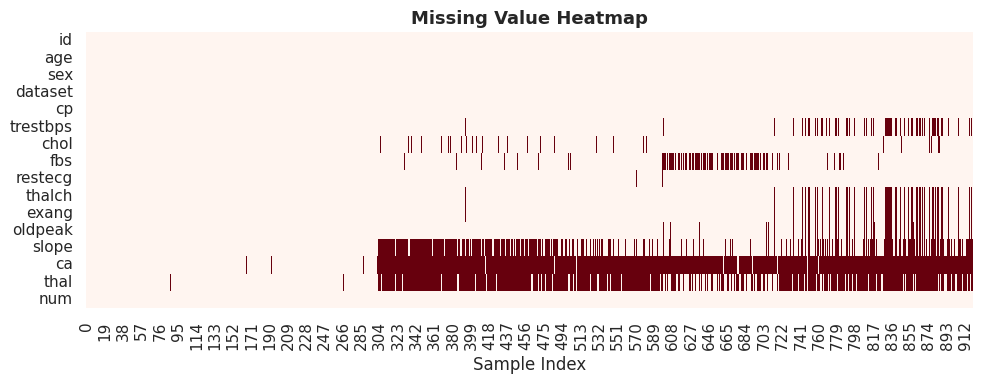

In [14]:
# Fig 1: Missing Value Heatmap
fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(df.isnull().T, cbar=False, yticklabels=df.columns, cmap='Reds', ax=ax)
ax.set_title('Missing Value Heatmap', fontsize=13, fontweight='bold')
ax.set_xlabel('Sample Index')
plt.tight_layout()
plt.savefig('eda_missing_heatmap.png', dpi=150)
plt.show()

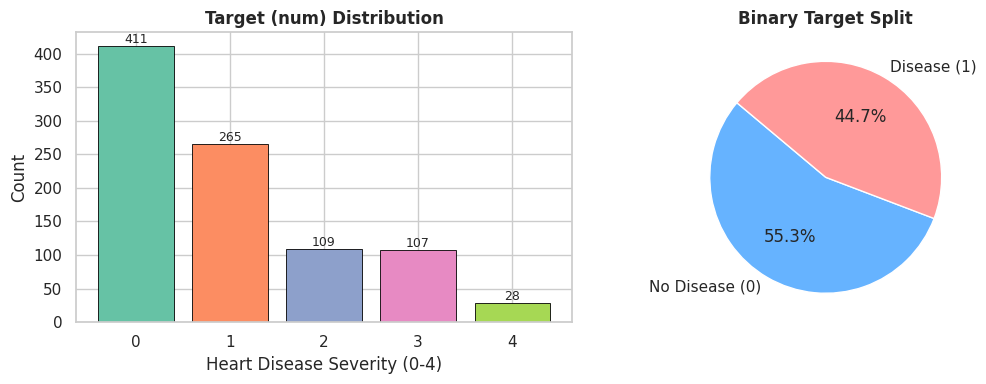

In [15]:
# Fig 2: Target Distribution
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
val_counts = df['num'].value_counts().sort_index()
colors = sns.color_palette('Set2', 5)
axes[0].bar(val_counts.index, val_counts.values, color=colors, edgecolor='black', linewidth=0.6)
axes[0].set_title('Target (num) Distribution', fontweight='bold')
axes[0].set_xlabel('Heart Disease Severity (0-4)')
axes[0].set_ylabel('Count')
for i, v in zip(val_counts.index, val_counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontsize=9)

binary = df['num'].apply(lambda x: 0 if x == 0 else 1)
bc = binary.value_counts()
axes[1].pie(bc, labels=['No Disease (0)', 'Disease (1)'], autopct='%1.1f%%',
            colors=['#66b3ff', '#ff9999'], startangle=140)
axes[1].set_title('Binary Target Split', fontweight='bold')
plt.tight_layout()
plt.savefig('eda_target_distribution.png', dpi=150)
plt.show()

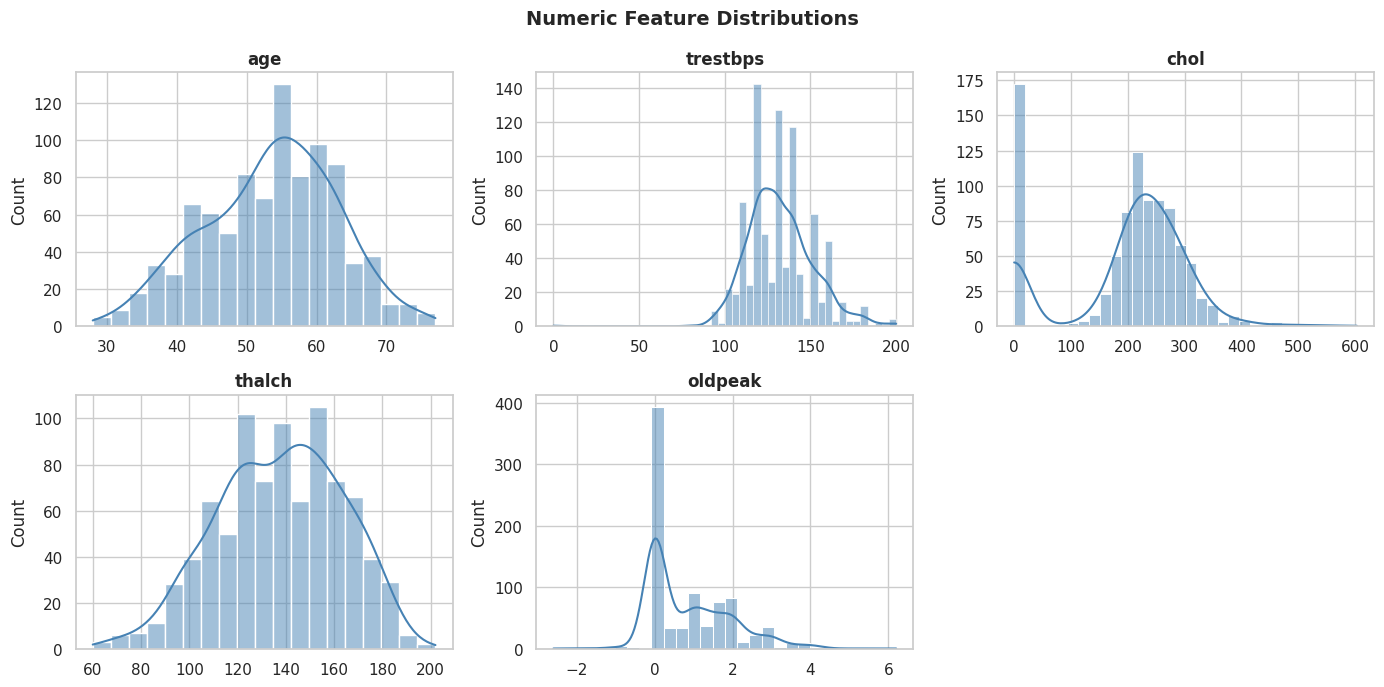

In [16]:
# Fig 3: Numeric Feature Distributions
num_cols = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak']
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    sns.histplot(df[col].dropna(), kde=True, ax=axes[i], color='steelblue')
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_xlabel('')
axes[-1].set_visible(False)
fig.suptitle('Numeric Feature Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_numeric_distributions.png', dpi=150)
plt.show()

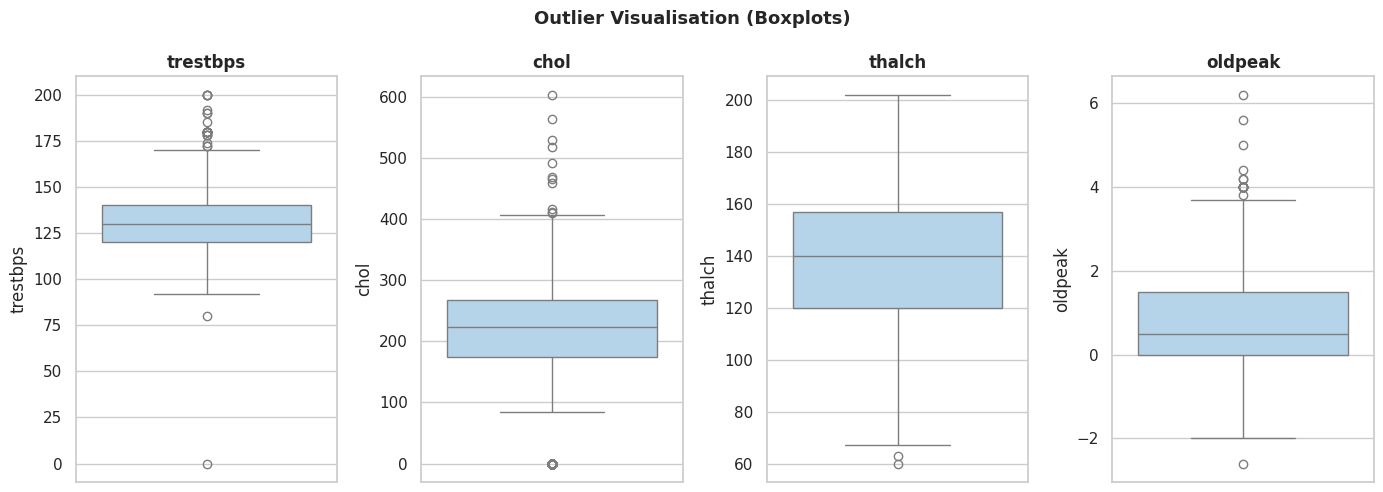

In [17]:
# Fig 4: Boxplots for Outlier Visualisation
outlier_cols = ['trestbps', 'chol', 'thalch', 'oldpeak']
fig, axes = plt.subplots(1, 4, figsize=(14, 5))
for i, col in enumerate(outlier_cols):
    sns.boxplot(y=df[col].dropna(), ax=axes[i], color='#AED6F1')
    axes[i].set_title(col, fontweight='bold')
fig.suptitle('Outlier Visualisation (Boxplots)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_boxplots.png', dpi=150)
plt.show()

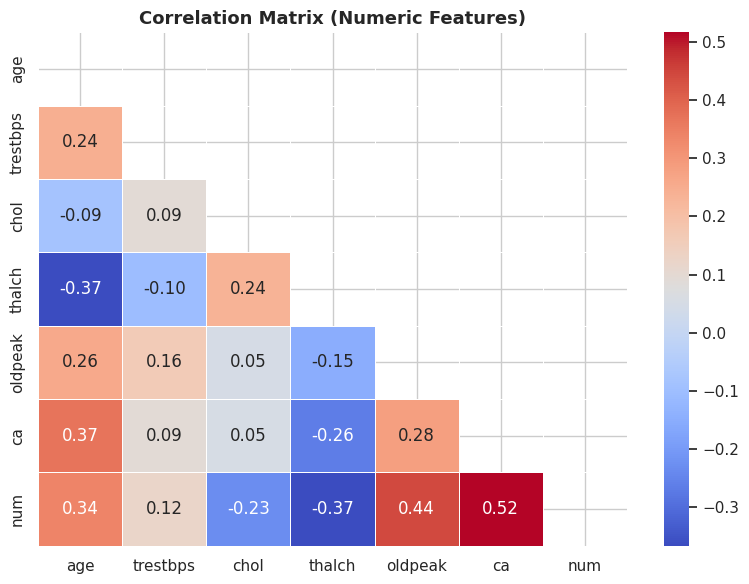

In [18]:
# Fig 5: Correlation Heatmap
# Using pairwise correlation (min_periods=1) to avoid dropping rows
# due to missing values in 'ca'
num_df = df[['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca', 'num']]
corr_matrix = num_df.corr(min_periods=1)

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, linewidths=0.5, ax=ax)
ax.set_title('Correlation Matrix (Numeric Features)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_correlation_heatmap.png', dpi=150)
plt.show()

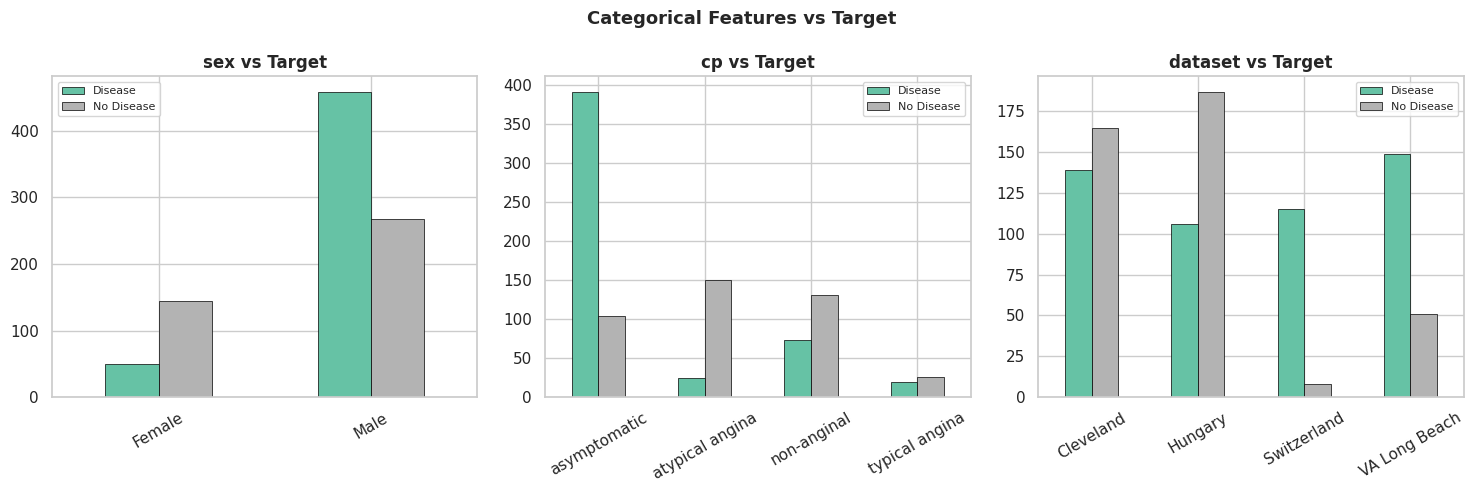

EDA complete.


In [19]:
# Fig 6: Categorical Features vs Target
cat_cols_plot = ['sex', 'cp', 'dataset']
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i, col in enumerate(cat_cols_plot):
    ct = pd.crosstab(df[col], df['num'].apply(lambda x: 'Disease' if x > 0 else 'No Disease'))
    ct.plot(kind='bar', ax=axes[i], colormap='Set2', edgecolor='black', linewidth=0.5, rot=30)
    axes[i].set_title(f'{col} vs Target', fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].legend(fontsize=8)
fig.suptitle('Categorical Features vs Target', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_categorical_vs_target.png', dpi=150)
plt.show()

print('EDA complete.')